# HAN 模型 — 药物重定向对比实验
与 HGTDR-3.ipynb 使用完全相同的数据预处理和嵌入，只替换 GNN 模型为 HAN

In [1]:
# Cell 1: Imports
from torch_geometric.nn import HANConv, Linear
from torch_geometric.loader import HGTLoader
from torch_geometric.data import HeteroData
import torch.nn.functional as F
import pickle
import torch.nn as nn
import pandas as pd
import numpy as np
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from utils import *
import random
import torch
import copy
from tqdm import tqdm

In [2]:
# Cell 2: 配置（与 HGT 版本完全一致）
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
node_type1 = 'drug'
node_type2 = 'disease'
rel = 'indication'

NODE2VEC_DIM   = 128
CHEMBERTA_DIM  = 767
PUBMEDBERT_DIM = 768

config = {
    'num_samples': 512,
    'batch_size': 164,
    'dropout': 0.5,
    'epochs': 300
}
print(f'设备: {device}')

设备: cuda:0


In [3]:
# Cell 3: 数据预处理（与 HGT 版本完全一致）
df = pd.read_csv('../data/kg.csv')

valid_rows = (
    ((df['x_type'] == 'drug') & (df['y_type'] == 'disease')) |
    ((df['x_type'] == 'disease') & (df['y_type'] == 'drug'))
)
drug_disease_pairs = df[(df['relation'] == rel) & valid_rows]

x_mask = drug_disease_pairs['x_type'].isin([node_type1, node_type2])
y_mask = drug_disease_pairs['y_type'].isin([node_type1, node_type2])
all_entities = pd.concat([
    drug_disease_pairs.loc[x_mask, ['x_type', 'x_index']].rename(columns={'x_type': 'type', 'x_index': 'index'}),
    drug_disease_pairs.loc[y_mask, ['y_type', 'y_index']].rename(columns={'y_type': 'type', 'y_index': 'index'})
])
valid_drugs    = set(all_entities[all_entities['type'] == node_type1]['index'].unique())
valid_diseases = set(all_entities[all_entities['type'] == node_type2]['index'].unique())

check_x = (
    (~df['x_type'].isin(['drug', 'disease'])) |
    ((df['x_type'] == 'drug')    & df['x_index'].isin(valid_drugs)) |
    ((df['x_type'] == 'disease') & df['x_index'].isin(valid_diseases))
)
check_y = (
    (~df['y_type'].isin(['drug', 'disease'])) |
    ((df['y_type'] == 'drug')    & df['y_index'].isin(valid_drugs)) |
    ((df['y_type'] == 'disease') & df['y_index'].isin(valid_diseases))
)
df_cleaned = df[check_x & check_y].reset_index(drop=True)

new_df = pd.DataFrame({
    0: df_cleaned['x_type'] + '::' + df_cleaned['x_index'].astype(str),
    1: df_cleaned['relation'],
    2: df_cleaned['y_type'] + '::' + df_cleaned['y_index'].astype(str)
})
df = new_df.drop_duplicates()
triplets = df.values.tolist()
print(f'三元组数量: {len(triplets)}')

/tmp/ipykernel_719962/3860392621.py:2: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/kg.csv')


三元组数量: 5683172


In [4]:
# Cell 4: 构建 entity_dictionary 和 edge_dictionary（与 HGT 版本完全一致）
entity_dictionary = {}
for src, _, dest in triplets:
    for node in [src, dest]:
        n_type, n_id = node.split('::', 1)
        type_dict = entity_dictionary.setdefault(n_type, {})
        if node not in type_dict:
            type_dict[node] = len(type_dict)

edge_dictionary = defaultdict(list)
for src, relation, dest in triplets:
    src_type  = src.split('::', 1)[0]
    dest_type = dest.split('::', 1)[0]
    edge_dictionary[(src_type, relation, dest_type)].append(
        (entity_dictionary[src_type][src], entity_dictionary[dest_type][dest])
    )
edge_dictionary = dict(edge_dictionary)

print('节点类型及数量:')
for k, v in entity_dictionary.items():
    print(f'  {k}: {len(v)}')

节点类型及数量:
  gene/protein: 27573
  drug: 1801
  disease: 1363
  effect/phenotype: 15082
  biological_process: 28642
  molecular_function: 11169
  cellular_component: 4176
  exposure: 780
  pathway: 2516
  anatomy: 14035


In [5]:
# Cell 5: 加载嵌入并归一化（与 HGT 版本完全一致）
node2vec_df   = pd.read_pickle('../data/node2vec_embeddings.pkl')
pubmedbert_df = pd.read_pickle('../data/pubmedbert_embeddings.pkl')
smiles_df     = pd.read_pickle('../data/smiles_embeddings.pkl')

node2vec_dict   = dict(zip(node2vec_df['id'],   node2vec_df['embedding']))
pubmedbert_dict = dict(zip(pubmedbert_df['id'], pubmedbert_df['embedding']))
smiles_dict     = dict(zip(smiles_df['id'],     smiles_df['embedding']))

def normalize_embeddings(emb_dict):
    keys   = list(emb_dict.keys())
    matrix = np.array([emb_dict[k] for k in keys], dtype=np.float32)
    matrix = StandardScaler().fit_transform(matrix)
    return dict(zip(keys, matrix))

node2vec_dict   = normalize_embeddings(node2vec_dict)
pubmedbert_dict = normalize_embeddings(pubmedbert_dict)
smiles_dict     = normalize_embeddings(smiles_dict)
print('嵌入归一化完成')

嵌入归一化完成


In [6]:
# Cell 6: 初始化 HeteroData 并填充嵌入（与 HGT 版本完全一致）
data = HeteroData()
for key in entity_dictionary.keys():
    num_nodes = len(entity_dictionary[key])
    dim = NODE2VEC_DIM + CHEMBERTA_DIM if key == 'drug' else NODE2VEC_DIM + PUBMEDBERT_DIM
    data[key].x  = torch.zeros((num_nodes, dim))
    data[key].id = torch.arange(num_nodes)

for key in edge_dictionary:
    data[key].edge_index = torch.transpose(
        torch.IntTensor(edge_dictionary[key]), 0, 1
    ).long().contiguous()

for node_type, mapping in tqdm(entity_dictionary.items(), desc='填充节点嵌入'):
    for entity_id, hgt_id in mapping.items():
        if entity_id in node2vec_dict:
            data[node_type].x[hgt_id, :NODE2VEC_DIM] = torch.tensor(
                np.array(node2vec_dict[entity_id], dtype=np.float32)
            )
        if node_type == 'drug':
            if entity_id in smiles_dict:
                data[node_type].x[hgt_id, NODE2VEC_DIM:] = torch.tensor(
                    np.array(smiles_dict[entity_id], dtype=np.float32)
                )
        else:
            if entity_id in pubmedbert_dict:
                data[node_type].x[hgt_id, NODE2VEC_DIM:] = torch.tensor(
                    np.array(pubmedbert_dict[entity_id], dtype=np.float32)
                )

print('节点维度:')
for k in data.node_types:
    print(f'  {k}: {data[k].x.shape}')

填充节点嵌入: 100%|██████████| 10/10 [00:03<00:00,  2.72it/s]

节点维度:
  gene/protein: torch.Size([27573, 896])
  drug: torch.Size([1801, 895])
  disease: torch.Size([1363, 896])
  effect/phenotype: torch.Size([15082, 896])
  biological_process: torch.Size([28642, 896])
  molecular_function: torch.Size([11169, 896])
  cellular_component: torch.Size([4176, 896])
  exposure: torch.Size([780, 896])
  pathway: torch.Size([2516, 896])
  anatomy: torch.Size([14035, 896])


In [7]:
# Cell 7: 加载训练/验证数据并创建 mask（与 HGT 版本完全一致）
with open('../data/CV data/train1.pkl', 'rb') as f:
    train_data = pickle.load(f)
with open('../data/CV data/val1.pkl', 'rb') as f:
    val_data = pickle.load(f)

drug_disease_num = train_data[(node_type1, rel, node_type2)]['edge_index'].shape[1]
mask = random.sample(range(drug_disease_num), int(drug_disease_num * 0.8))
train_data[(node_type1, rel, node_type2)]['mask'] = torch.zeros(drug_disease_num, dtype=torch.bool)
train_data[(node_type1, rel, node_type2)]['mask'][mask] = True
train_data[(node_type2, rel, node_type1)]['mask'] = torch.zeros(drug_disease_num, dtype=torch.bool)
train_data[(node_type2, rel, node_type1)]['mask'][mask] = True
print(f'训练集 indication 边数: {drug_disease_num}')

训练集 indication 边数: 7510


In [8]:
# Cell 8: HAN 模型定义
# HAN 与 HGT 的核心区别：
#   HGT - 对每种边类型分别学习注意力，节点类型感知
#   HAN - 先在同类型边内做节点级注意力，再跨元路径做语义级注意力

class HAN(nn.Module):
    def __init__(self, hidden_channels, out_channels, num_heads, num_layers, dropout, metadata):
        super().__init__()

        # 输入投影层：每种节点类型各一个，与 HGT 相同
        self.lin_dict = nn.ModuleDict()
        for node_type in train_data.node_types:
            self.lin_dict[node_type] = Linear(-1, hidden_channels)

        # HANConv 层
        # HANConv 内部自动处理所有元路径的节点级 + 语义级注意力
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(
                HANConv(
                    in_channels=hidden_channels,
                    out_channels=hidden_channels,
                    metadata=metadata,
                    heads=num_heads,
                    dropout=dropout
                )
            )

        self.lin = nn.Linear(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_dict, edge_index_dict):
        # 输入投影
        x_dict = {
            node_type: self.dropout(F.relu(self.lin_dict[node_type](x)))
            for node_type, x in x_dict.items()
            if node_type in self.lin_dict
        }

        # 多层 HANConv
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {k: F.relu(v) for k, v in x_dict.items() if v is not None}

        drug_out    = self.lin(x_dict[node_type1])
        disease_out = self.lin(x_dict[node_type2])
        return F.relu(drug_out), F.relu(disease_out)


class MLPPredictor(nn.Module):
    def __init__(self, channel_num, dropout):
        super().__init__()
        self.L1      = nn.Linear(channel_num * 2, channel_num)
        self.L2      = nn.Linear(channel_num, 1)
        self.bn      = nn.BatchNorm1d(num_features=channel_num)
        self.dropout = nn.Dropout(0.2)

    def forward(self, drug_embeddings, disease_embeddings):
        x = torch.cat((drug_embeddings, disease_embeddings), dim=1)
        x = F.relu(self.bn(self.L1(x)))
        x = self.dropout(x)
        x = self.L2(x)
        return x


def compute_loss(scores, labels):
    pos_weights = torch.clone(labels)
    pos_weights[pos_weights == 1] = ((labels == 0).sum() / labels.shape[0])
    pos_weights[pos_weights == 0] = ((labels == 1).sum() / labels.shape[0])
    return F.binary_cross_entropy_with_logits(scores, labels, pos_weight=pos_weights)


def define_model(dropout):
    GNN = HAN(
        hidden_channels=64,
        out_channels=64,
        num_heads=8,
        num_layers=3,
        dropout=dropout,
        metadata=train_data.metadata()
    )
    pred  = MLPPredictor(64, dropout)
    model = nn.Sequential(GNN, pred)
    model.to(device)
    return GNN, pred, model


def define_loaders(config):
    kwargs = {'batch_size': config['batch_size'], 'num_workers': 8, 'persistent_workers': True}
    train_loader = HGTLoader(train_data, num_samples=[config['num_samples']] * 3,
                             shuffle=True, input_nodes=(node_type1, None), **kwargs)
    val_loader   = HGTLoader(val_data,   num_samples=[config['num_samples']] * 3,
                             shuffle=True, input_nodes=(node_type1, None), **kwargs)
    return train_loader, val_loader

In [9]:
# Cell 9: Batch 构建函数（与 HGT 版本完全一致）
def edge_exists(edges, edge):
    edges = edges.to(device)
    edge  = edge.to(device)
    return (edges == edge).all(dim=0).sum() > 0


def make_batch(batch):
    batch_size  = batch[node_type1].batch_size
    edge_index  = batch[(node_type1, rel, node_type2)]['edge_index']
    mask        = batch[(node_type1, rel, node_type2)]['mask']
    batch_index = (edge_index[0] < batch_size)
    edge_index  = edge_index[:, batch_index]
    mask        = mask[batch_index]
    edge_label_index = edge_index[:, mask]
    pos_num     = edge_label_index.shape[1]
    edge_label  = torch.ones(pos_num)
    neg_edges_source, neg_edges_dest = [], []
    while len(neg_edges_source) < pos_num:
        source   = random.randint(0, batch_size - 1)
        dest     = random.randint(0, batch[node_type2].x.shape[0] - 1)
        neg_edge = torch.Tensor([[source], [dest]])
        if not edge_exists(edge_index, neg_edge):
            neg_edges_source.append(source)
            neg_edges_dest.append(dest)
    neg_edges        = torch.tensor([neg_edges_source, neg_edges_dest])
    edge_label_index = torch.cat((edge_label_index, neg_edges), dim=1)
    edge_label       = torch.cat((edge_label, torch.zeros(neg_edges.shape[1])), dim=0)
    edge_index       = edge_index[:, ~mask]
    batch[(node_type1, rel, node_type2)]['edge_index']       = edge_index
    batch[(node_type1, rel, node_type2)]['edge_label_index'] = edge_label_index
    batch[(node_type1, rel, node_type2)]['edge_label']       = edge_label
    batch[(node_type2, rel, node_type1)]['edge_index']       = edge_index
    temp = copy.copy(batch[(node_type2, rel, node_type1)]['edge_index'][0])
    batch[(node_type2, rel, node_type1)]['edge_index'][0] = batch[(node_type2, rel, node_type1)]['edge_index'][1]
    batch[(node_type2, rel, node_type1)]['edge_index'][1] = temp
    return batch


def make_test_batch(batch):
    batch_size       = batch[node_type1].batch_size
    edge_index       = batch[(node_type1, rel, node_type2)]['edge_index']
    edge_label_index = batch[(node_type1, rel, node_type2)]['edge_label_index']
    edge_label       = batch[(node_type1, rel, node_type2)]['edge_label']
    source, dest     = [], []
    for i in range(edge_label_index.shape[1]):
        if (edge_label_index[0, i] in batch[node_type1]['id'] and
            edge_label_index[1, i] in batch[node_type2]['id'] and
            ((batch[node_type1]['id'] == edge_label_index[0, i]).nonzero(as_tuple=True)[0]) < batch_size):
            if edge_label[i] == 1:
                source.append((batch[node_type1]['id'] == edge_label_index[0, i]).nonzero(as_tuple=True)[0])
                dest.append((batch[node_type2]['id'] == edge_label_index[1, i]).nonzero(as_tuple=True)[0])
    edge_label_index    = torch.zeros(2, len(source)).long()
    edge_label_index[0] = torch.tensor(source)
    edge_label_index[1] = torch.tensor(dest)
    pos_num    = edge_label_index.shape[1]
    edge_label = torch.ones(pos_num)
    neg_edges_source, neg_edges_dest = [], []
    while len(neg_edges_source) < pos_num:
        source_node  = random.randint(0, batch_size - 1)
        dest_node    = random.randint(0, batch[node_type2].x.shape[0] - 1)
        neg_edge_orig = torch.Tensor([[batch[node_type1]['id'][source_node]],
                                      [batch[node_type2]['id'][dest_node]]])
        if not edge_exists(data[(node_type1, rel, node_type2)]['edge_index'], neg_edge_orig):
            neg_edges_source.append(source_node)
            neg_edges_dest.append(dest_node)
    neg_edges        = torch.tensor([neg_edges_source, neg_edges_dest])
    edge_label_index = torch.cat((edge_label_index, neg_edges), dim=1)
    edge_label       = torch.cat((edge_label, torch.zeros(neg_edges.shape[1])), dim=0)
    batch[(node_type1, rel, node_type2)]['edge_label_index'] = edge_label_index
    batch[(node_type1, rel, node_type2)]['edge_label']       = edge_label
    return batch

In [10]:
# Cell 10: 训练与评估函数（与 HGT 版本完全一致）
def train(GNN, pred, model, loader, optimizer):
    model.train()
    total_examples = total_loss = 0
    for batch in iter(loader):
        optimizer.zero_grad()
        batch = make_batch(batch)
        batch = batch.to(device)
        edge_label_index = batch[(node_type1, rel, node_type2)]['edge_label_index']
        edge_label       = batch[(node_type1, rel, node_type2)]['edge_label']
        if edge_label.shape[0] == 0:
            continue
        drug_embeddings, disease_embeddings = GNN(batch.x_dict, batch.edge_index_dict)
        out  = pred(drug_embeddings[edge_label_index[0]],
                    disease_embeddings[edge_label_index[1]])[:, 0]
        loss = compute_loss(out, edge_label)
        loss.backward()
        optimizer.step()
        total_examples += edge_label_index.shape[1]
        total_loss     += loss.item() * edge_label_index.shape[1]
    return total_loss / total_examples


@torch.no_grad()
def test(GNN, pred, model, loader):
    model.eval()
    out, labels = torch.tensor([]).to(device), torch.tensor([]).to(device)
    source, dest = torch.tensor([]).to(device), torch.tensor([]).to(device)
    for batch in iter(loader):
        batch = make_test_batch(batch)
        batch = batch.to(device)
        drug_embeddings, disease_embeddings = GNN(batch.x_dict, batch.edge_index_dict)
        edge_label_index = batch[(node_type1, rel, node_type2)]['edge_label_index']
        edge_label       = batch[(node_type1, rel, node_type2)]['edge_label']
        if edge_label.shape[0] == 0:
            continue
        c         = drug_embeddings[edge_label_index[0]]
        d         = disease_embeddings[edge_label_index[1]]
        batch_out = pred(c, d)[:, 0]
        labels    = torch.cat((labels, edge_label))
        out       = torch.cat((out, batch_out))
        source    = torch.cat((source, batch[node_type1]['id'][edge_label_index[0]]))
        dest      = torch.cat((dest,   batch[node_type2]['id'][edge_label_index[1]]))
    loss = compute_loss(out, labels)
    return out, labels, source, dest, loss.cpu().numpy()

HAN Training:   0%|          | 1/300 [00:08<43:52,  8.81s/it]

Epoch: 00, Loss: 0.4644, ValLoss: 0.5038 

Epoch 0: LR = 0.001000


HAN Training:   1%|          | 2/300 [00:16<39:51,  8.03s/it]

Epoch: 01, Loss: 0.4442, ValLoss: 0.5003 

Epoch 1: LR = 0.001000


HAN Training:   1%|          | 3/300 [00:23<38:33,  7.79s/it]

...

HAN Training: 100%|█████████▉| 299/300 [37:21<00:07,  7.52s/it]

Epoch: 298, Loss: 0.2759, ValLoss: 0.2961 

Epoch 298: LR = 0.000000


HAN Training: 100%|██████████| 300/300 [37:29<00:00,  7.50s/it]

Epoch: 299, Loss: 0.2737, ValLoss: 0.2939 

Epoch 299: LR = 0.000000


AUPR: 0.874 



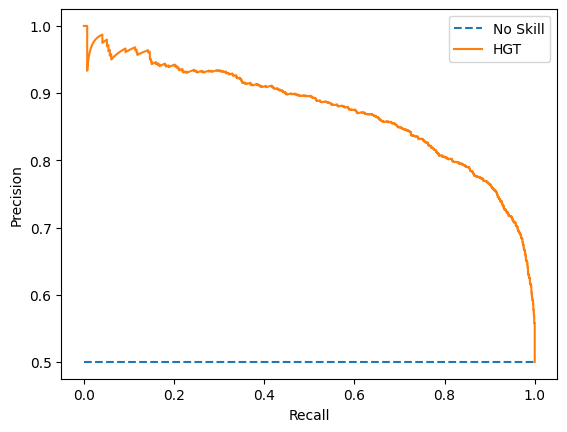

AUROC: 0.891 



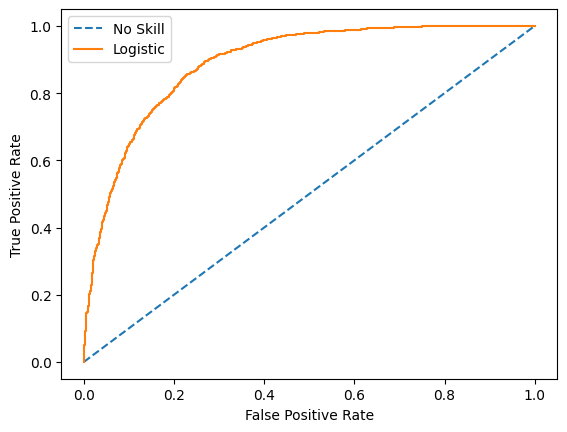

In [11]:
# Cell 11: 训练主循环（与 HGT 版本完全一致）
def run(config):
    losses, val_losses = [], []

    train_loader, val_loader = define_loaders(config)
    GNN, pred, model         = define_model(config['dropout'])

    optimizer = torch.optim.AdamW(model.parameters())
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config['epochs'], eta_min=0, last_epoch=-1
    )

    for epoch in tqdm(range(config['epochs']), desc='HAN Training'):
        loss = train(GNN, pred, model, train_loader, optimizer)
        out, labels, source, dest, val_loss = test(GNN, pred, model, val_loader)
        write_to_out(f'Epoch: {epoch:02d}, Loss: {loss:.4f}, ValLoss: {val_loss:.4f} \n')
        losses.append(loss)
        val_losses.append(val_loss)
        plot_losses(losses, val_losses)
        scheduler.step()
        print(f'Epoch {epoch}: LR = {scheduler.get_last_lr()[0]:.6f}')

    torch.save(model.state_dict(), '../out/han_saved_model.h5')

    out, labels, source, dest, val_loss = test(GNN, pred, model, val_loader)
    AUPR(out, labels)
    AUROC(out, labels)


run(config)